In [153]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and filter data
df = pd.read_csv('house_prices.csv')
# Drop rows where price is missing or 0
df = df[df['price'].notna() & (df['price'] > 0)]
df.fillna({
    'bedrooms': df['bedrooms'].mean(),
    'sqft_living': df['sqft_living'].mean(),
    'sqft_lot': df['sqft_lot'].mean(),
    'sqft_above': df['sqft_above'].mean(),
    'bathrooms': df['bathrooms'].mean()
}, inplace=True)

# Filter for bedrooms = 3, 4, or 5
mask = df['bedrooms'].isin([3, 4, 5])
filtered_df = df[mask]


In [154]:
# Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = filtered_df[features]
y = filtered_df['price']
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [155]:
# Train model
lr_model = LinearRegression() #Multi Feature Predictions Model
lr_model.fit(X_train, y_train)
print(f"Model R² Score: {lr_model.score(X_test, y_test):.2f}")

Model R² Score: 0.02


In [156]:
# Predict and evaluate Linear Regression Model Multi Feature 
lr_y_pred = lr_model.predict(X_test)
print(f"First 5 predictions: {lr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
lr_errors = y_test.values - lr_y_pred
print(f"First 5 prediction errors: {lr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(lr_errors)):.1f}")



First 5 predictions: [862581.84409413 645864.44366415 547443.94894598 783944.48768965
 729904.39365619]
First 5 actual prices: [799000. 347000. 295000. 755000. 795000.]
First 5 prediction errors: [ -63581.84409413 -298864.44366415 -252443.94894598  -28944.48768965
   65095.60634381]
Mean Absolute Error: 223556.9


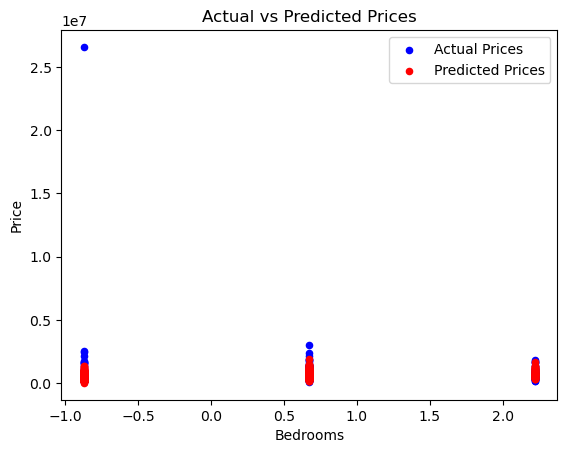

In [159]:
# Linear Regression Model Actual vs Predicted Prices
plot_df = pd.DataFrame({
    'bedrooms': X_test[:,0],
    'actual_price': y_test.values,
    'predicted_price': lr_y_pred
})

# Create scatter plot
ax = plot_df.plot(kind='scatter', x='bedrooms', y='actual_price', color='blue', label='Actual Prices')
plot_df.plot(kind='scatter', x='bedrooms', y='predicted_price', color='red', label='Predicted Prices', ax=ax)
ax.set_xlabel('Bedrooms')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted Prices')
plt.savefig('actual_vs_predicted.png')
plt.show()

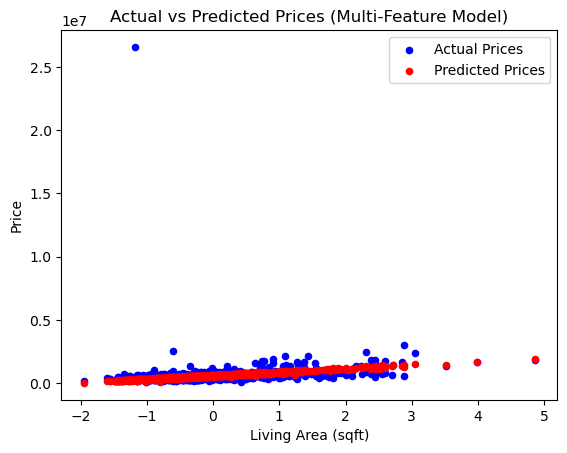

In [106]:
# Visualize predictions Multi-Feature (using sqft_living for x-axis)
# Convert X_test back to DataFrame with original (unscaled) values

lr_plot_df = pd.DataFrame({
    'sqft_living': X_test[:, 1],           # NumPy array
    'actual_price': y_test.values,         # Convert Series to NumPy
    'predicted_price': lr_y_pred           # Already NumPy
})
lr_ax = lr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
lr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='red', label='Predicted Prices', ax=lr_ax)
lr_ax.set_xlabel('Living Area (sqft)')
lr_ax.set_ylabel('Price')
lr_ax.set_title('Actual vs Predicted Prices (Multi-Feature Model)')
plt.savefig('multi_feature_predictions.png')
plt.show()



In [107]:
# Check correlation to optimize features
print(filtered_df[['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']].corr())

             bedrooms  sqft_living  sqft_lot  sqft_above  bathrooms
bedrooms     1.000000     0.507368  0.060922    0.395771   0.406453
sqft_living  0.507368     1.000000  0.191683    0.858371   0.724922
sqft_lot     0.060922     0.191683  1.000000    0.200189   0.088984
sqft_above   0.395771     0.858371  0.200189    1.000000   0.647157
bathrooms    0.406453     0.724922  0.088984    0.647157   1.000000


In [108]:
# Train model Decision Tree Regressor
dtr_model = DecisionTreeRegressor(random_state=42) #Decision Tree Prediction Model
dtr_model.fit(X_train, y_train)
print(f"Decision Tree R² Score: {dtr_model.score(X_test, y_test):.2f}")


Decision Tree R² Score: -0.23


In [109]:
#Predict and evaluate Decision Tree Regressor
dtr_y_pred = dtr_model.predict(X_test)
print(f"First 5 predictions: {dtr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
dtr_errors = y_test.values - dtr_y_pred
print(f"First 5 prediction errors: {dtr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(dtr_errors)):.1f}")

First 5 predictions: [1640000.  594950.  479500.  980000.  515500.]
First 5 actual prices: [799000. 347000. 295000. 755000. 795000.]
First 5 prediction errors: [-841000. -247950. -184500. -225000.  279500.]
Mean Absolute Error: 285151.3


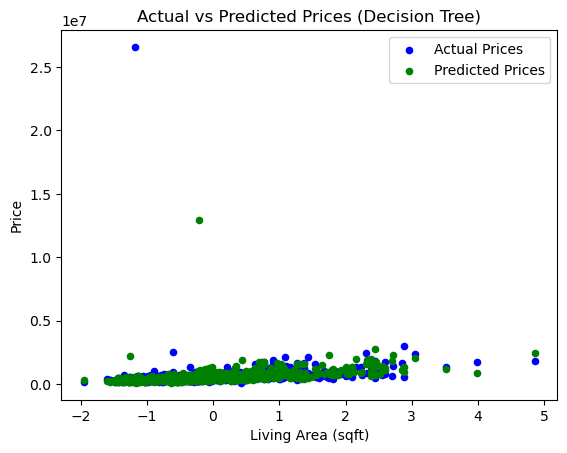

In [110]:
# Visualize predictions Decision Tree (using sqft_living for x-axis) 
dtr_plot_df = pd.DataFrame({
        'sqft_living': X_test[:, 1],            # NumPy array
        'actual_price': y_test.values,          # Convert Series to NumPy
        'predicted_price': dtr_y_pred           # Already NumPy
})
dtr_ax = dtr_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
dtr_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='green', label='Predicted Prices', ax=dtr_ax)
dtr_ax.set_xlabel('Living Area (sqft)')
dtr_ax.set_ylabel('Price')
dtr_ax.set_title('Actual vs Predicted Prices (Decision Tree)')
plt.savefig('decision_tree_predictions.png')
plt.show()

In [111]:
# Scale features (important for KNN)
knn_scaler = StandardScaler()
X_train_scaled = knn_scaler.fit_transform(X_train)
X_test_scaled = knn_scaler.transform(X_test)

In [112]:
# Train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
print(f"KNN R² Score: {knn_model.score(X_test_scaled, y_test):.2f}")

KNN R² Score: 0.02


In [113]:
# Predict and evaluate
knn_y_pred = knn_model.predict(X_test_scaled)
print(f"First 5 predictions: {knn_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
knn_errors = y_test.values - knn_y_pred
print(f"First 5 prediction errors: {knn_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(knn_errors)):.1f}")

First 5 predictions: [1093780.  740000.  508399.  949000.  567900.]
First 5 actual prices: [799000. 347000. 295000. 755000. 795000.]
First 5 prediction errors: [-294780. -393000. -213399. -194000.  227100.]
Mean Absolute Error: 222241.5


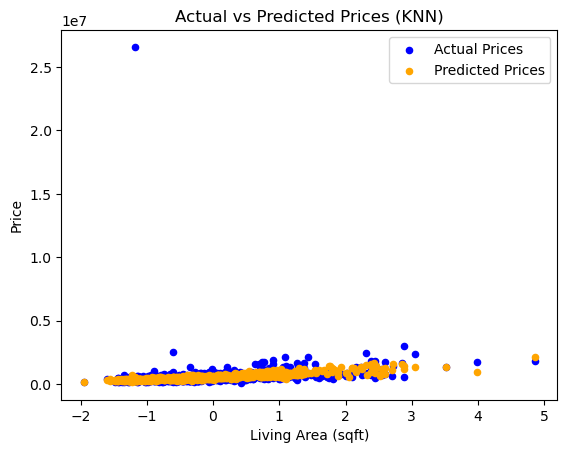

In [114]:
# Visualize predictions (using sqft_living for x-axis)
knn_plot_df = pd.DataFrame({
        'sqft_living': X_test[:, 1],            # NumPy array
        'actual_price': y_test.values,           # Convert Series to NumPy
        'predicted_price': knn_y_pred           # Already NumPy
     })
knn_ax = knn_plot_df.plot(kind='scatter', x='sqft_living', y='actual_price', color='blue', label='Actual Prices')
knn_plot_df.plot(kind='scatter', x='sqft_living', y='predicted_price', color='orange', label='Predicted Prices', ax=knn_ax)
knn_ax.set_xlabel('Living Area (sqft)')
knn_ax.set_ylabel('Price')
knn_ax.set_title('Actual vs Predicted Prices (KNN)')
plt.savefig('knn_predictions.png')
plt.show()

In [115]:
# Compare model performance
print("\nModel Performance Comparison:")
print(f"Linear Regression R²: {lr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(lr_errors)):.1f}")
print(f"Decision Tree R²: {dtr_model.score(X_test, y_test):.2f}, MAE: {np.mean(np.abs(dtr_errors)):.1f}")
print(f"KNN R²: {knn_model.score(X_test_scaled, y_test):.2f}, MAE: {np.mean(np.abs(knn_errors)):.1f}")


Model Performance Comparison:
Linear Regression R²: 0.02, MAE: 223556.9
Decision Tree R²: -0.23, MAE: 285151.3
KNN R²: 0.02, MAE: 222241.5


In [116]:
# Calculate feature importance
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
importance = dtr_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(feature_importance.sort_values(by='Importance', ascending=False))

  


Feature Importance:
       Feature  Importance
1  sqft_living    0.470050
2     sqft_lot    0.394645
3   sqft_above    0.066742
4    bathrooms    0.054000
0     bedrooms    0.014564


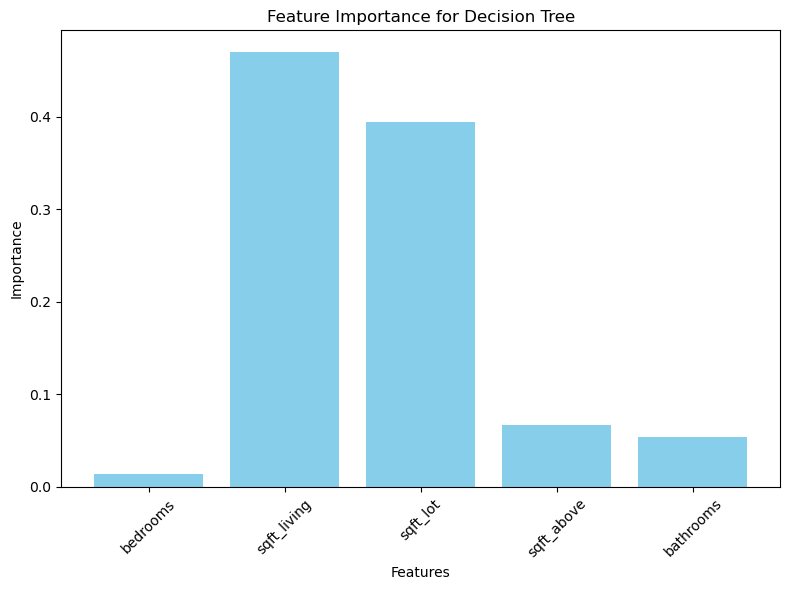

In [117]:
# Visualize feature importance
plt.figure(figsize=(8, 6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'], color='skyblue')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance for Decision Tree')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()


In [118]:
# Example: Exclude low-importance feature (e.g., bedrooms )
exclude_bedrooms_features = ['sqft_lot', 'sqft_living', 'sqft_above', 'bathrooms']  # Adjust based on output
X = filtered_df[exclude_bedrooms_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
xbedroomsdtr_model = DecisionTreeRegressor(random_state=42)
xbedroomsdtr_model.fit(X_train, y_train)
print(f"Refined Decision Tree R² Score: {xbedroomsdtr_model.score(X_test, y_test):.2f}")
xbedroomsdtr_y_pred = xbedroomsdtr_model.predict(X_test)
xbedroomsdtr_errors = y_test.values - xbedroomsdtr_y_pred 
print(f"Refined MAE: {np.mean(np.abs(xbedroomsdtr_errors)):.1f}")

Refined Decision Tree R² Score: -0.24
Refined MAE: 290275.3


In [119]:
# Define parameter grid for decision tree
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [120]:
# Grid search with cross-validation
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

In [121]:
# Best model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV R² Score: {grid_search.best_score_:.2f}")


Best Parameters: {'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV R² Score: 0.40


In [122]:
# Evaluate on test set
best_y_pred = best_model.predict(X_test)
best_test_r2 = best_model.score(X_test, y_test)
print(f"Test R² Score with Best Model: {best_test_r2:.2f}")
best_errors = y_test.values - best_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(best_errors)):.1f}")

Test R² Score with Best Model: 0.03
Test MAE with Best Model: 216127.9


In [123]:
# Define parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # Manhattan (1) or Euclidean (2) distance
        }
   

In [124]:
# Grid search with cross-validation
knn_grid_search = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring='r2')
knn_grid_search.fit(X_train_scaled, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='r2')

In [125]:
# Best model
knn_best_model = knn_grid_search.best_estimator_
print(f"Best Parameters: {knn_grid_search.best_params_}")
print(f"Best CV R² Score: {knn_grid_search.best_score_:.2f}")


Best Parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
Best CV R² Score: 0.38


In [126]:
# Evaluate on test set
knn_y_pred = knn_best_model.predict(X_test_scaled)
knn_test_r2 = knn_best_model.score(X_test_scaled, y_test)
print(f"Test R² Score with Best Model: {knn_test_r2:.2f}")
knn_errors = y_test.values - knn_y_pred
print(f"Test MAE with Best Model: {np.mean(np.abs(knn_errors)):.1f}")

Test R² Score with Best Model: 0.02
Test MAE with Best Model: 221832.8


In [127]:
 # Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = filtered_df[features]
y = filtered_df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [128]:
# Train Random Forest
rfr_model = RandomForestRegressor(random_state=42, n_estimators=100)
rfr_model.fit(X_train, y_train)
print(f"Random Forest R² Score: {rfr_model.score(X_test, y_test):.2f}")

    

Random Forest R² Score: 0.02


In [129]:
# Predict and evaluate
rfr_y_pred = rfr_model.predict(X_test)
print(f"First 5 predictions: {rfr_y_pred[:5]}")
print(f"First 5 actual prices: {y_test.values[:5]}")
rfr_errors = y_test.values - rfr_y_pred
print(f"First 5 prediction errors: {rfr_errors[:5]}")
print(f"Mean Absolute Error: {np.mean(np.abs(rfr_errors)):.1f}")

     

First 5 predictions: [1015253.68        707213.36        440340.07333334  842745.33333333
  569334.69      ]
First 5 actual prices: [799000. 347000. 295000. 755000. 795000.]
First 5 prediction errors: [-216253.68       -360213.36       -145340.07333334  -87745.33333333
  225665.31      ]
Mean Absolute Error: 215298.2


In [130]:
# Feature importance Random Forest
rfr_importance = rfr_model.feature_importances_
rfr_feature_importance = pd.DataFrame({'Feature': features, 'Importance': importance})
print("\nFeature Importance:")
print(rfr_feature_importance.sort_values(by='Importance', ascending=False))


Feature Importance:
       Feature  Importance
1  sqft_living    0.470050
2     sqft_lot    0.394645
3   sqft_above    0.066742
4    bathrooms    0.054000
0     bedrooms    0.014564


In [131]:
# rfr_model is your trained RandomForestRegressor and rfr_y_pred = rfr_model.predict(X_test)
mse = mean_squared_error(y_test, rfr_y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfr_y_pred)
print(f"Random Forest - MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

Random Forest - MSE: 1069432845659.05, RMSE: 1034133.86, R²: 0.02


In [132]:
rfr_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
rfr = RandomForestRegressor(random_state=42)
rfr_grid_search = GridSearchCV(rfr, rfr_param_grid, cv=5, scoring='neg_mean_squared_error')
rfr_grid_search.fit(X_train, y_train)
print("Best parameters:", rfr_grid_search.best_params_)



Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [133]:
# Retrain with best params
rfr_best = rfr_grid_search.best_estimator_
rfr_y_pred_best = rfr_best.predict(X_test)
rfr_mse_best = mean_squared_error(y_test, rfr_y_pred_best)
rfr_rmse_best = np.sqrt(rfr_mse_best)
rfr_r2_best = r2_score(y_test, rfr_y_pred_best)
print(f"Optimized Random Forest - MSE: {rfr_mse_best:.2f}, RMSE: {rfr_rmse_best:.2f}, R²: {rfr_r2_best:.2f}")

Optimized Random Forest - MSE: 1064295891913.08, RMSE: 1031647.17, R²: 0.02


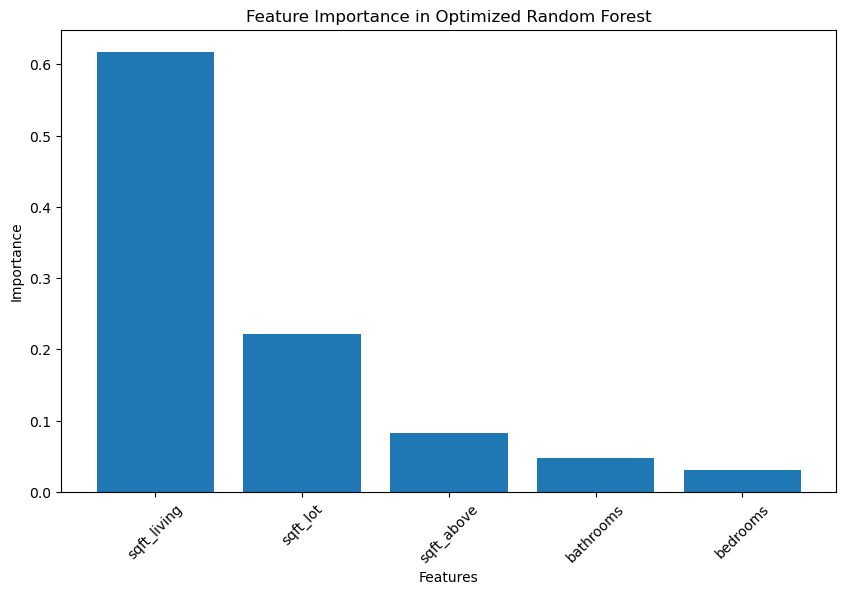

In [134]:
rfr_importances = rfr_best.feature_importances_
rfr_feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': rfr_feature_names, 'Importance': rfr_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Importance'])
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in Optimized Random Forest')
plt.savefig('random_forest_feature_importance.png')
plt.show()


In [135]:
# Train XGBoost
xgb = XGBRegressor(random_state=42, n_estimators=100, max_depth=5)
xgb.fit(X_train, y_train)
xgb_y_pred = xgb.predict(X_test)


In [136]:
# Evaluate
xgb_mse = mean_squared_error(y_test, xgb_y_pred )
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_y_pred)
print(f"XGBoost - MSE: {xgb_mse:.2f}, RMSE: {xgb_rmse:.2f}, R²: {xgb_r2:.2f}")

XGBoost - MSE: 1106007724683.17, RMSE: 1051669.02, R²: -0.02


In [137]:
# Comparison table
results_rfr_xgb = pd.DataFrame({
    'Model': ['Random Forest (Optimized)', 'XGBoost'],
    'MSE': [rfr_mse_best, xgb_mse],
    'RMSE': [rfr_rmse_best, xgb_rmse],
    'R²': [rfr_r2_best, xgb_r2]
})
print(results_rfr_xgb)

                       Model           MSE          RMSE        R²
0  Random Forest (Optimized)  1.064296e+12  1.031647e+06  0.021639
1                    XGBoost  1.106008e+12  1.051669e+06 -0.016705


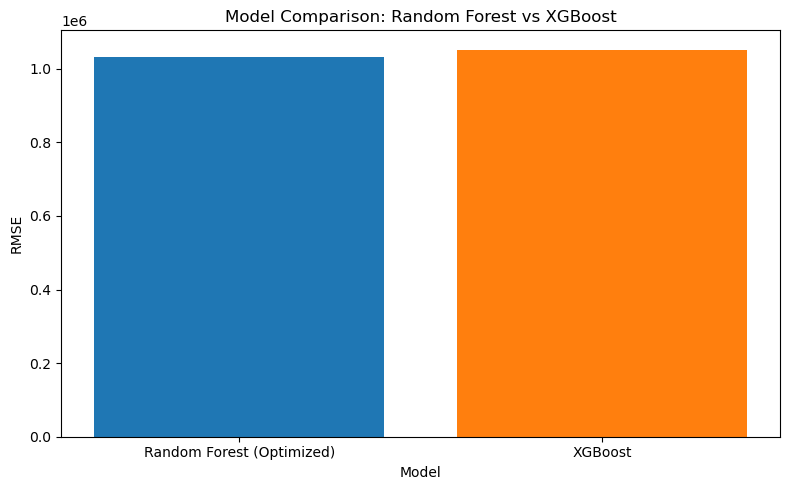

In [138]:
# Bar chart for RMSE
plt.figure(figsize=(8, 5))
plt.bar(results_rfr_xgb['Model'], results_rfr_xgb['RMSE'], color=['#1f77b4', '#ff7f0e'])  # Blue, orange for visibility
plt.xlabel('Model')
plt.ylabel('RMSE')

plt.title('Model Comparison: Random Forest vs XGBoost')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()


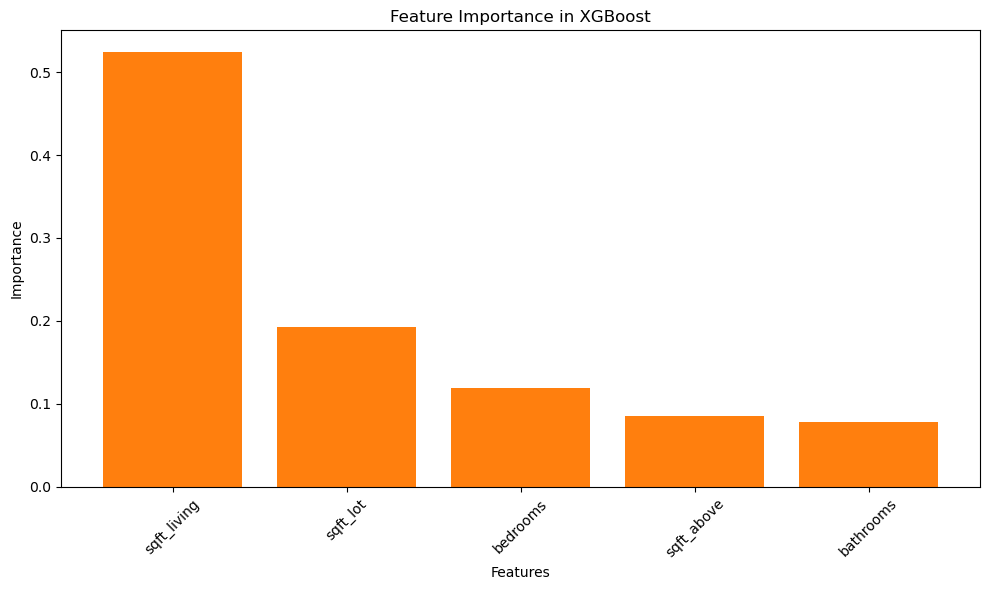

In [139]:
xgb_importances = xgb.feature_importances_
xgb_feature_names = X_train.columns
xgb_importance_df = pd.DataFrame({'Feature': xgb_feature_names, 'Importance': xgb_importances})
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(xgb_importance_df['Feature'], xgb_importance_df['Importance'], color='#ff7f0e')
plt.xticks(rotation=45)
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance in XGBoost')
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png')
plt.show()


               Model           MSE          RMSE        R²
0  Linear Regression  1.064257e+12  1.031628e+06  0.021675
1      Random Forest  1.064296e+12  1.031647e+06  0.021639
2            XGBoost  1.106008e+12  1.051669e+06 -0.016705


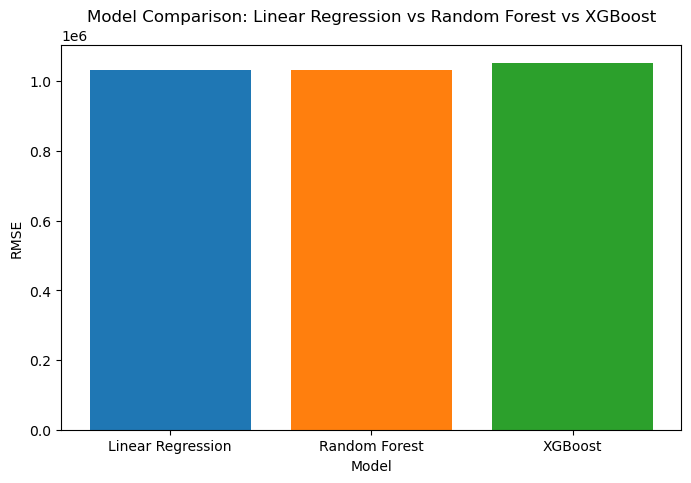

In [140]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MSE': [mean_squared_error(y_test, lr_y_pred), rfr_mse_best, xgb_mse],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_y_pred)), rfr_rmse_best, xgb_rmse],
    'R²': [r2_score(y_test, lr_y_pred), rfr_r2_best, xgb_r2]
})
print(results)
plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('Model Comparison: Linear Regression vs Random Forest vs XGBoost')
plt.savefig('model_comparison.png')
plt.show()
